# Griffiths Problem 1.14 -- the probability current, and why it *is* Kirchhoff's law
### $\dfrac{dP_{ab}}{dt}=J(a,t)-J(b,t)$ proved in SymPy, watched flow in Torch, read as a circuit

Probability is conserved: whatever leaves the region $(a,b)$ has to flow out through its ends. The
rate is the **probability current**
$$J(x,t)=\frac{i\hbar}{2m}\Big(\Psi\,\frac{\partial\Psi^*}{\partial x}-\Psi^*\frac{\partial\Psi}{\partial x}\Big),$$
and the bookkeeping is the **continuity equation** $\partial_t\rho+\partial_x J=0$, whose integrated
form is $dP_{ab}/dt=J(a,t)-J(b,t)$.

That is the *same equation* an electrical engineer calls **charge conservation**: $\partial_t\rho_q
+\partial_x J_q=0$, and over a node, $I_\text{in}-I_\text{out}=dQ/dt$ -- **Kirchhoff's Current Law**,
the constraint SPICE enforces at every node. This notebook **proves the continuity equation in
SymPy**, computes $J$ for Problem 1.9's wavefunction (it's zero -- Griffiths' "not very pithy"
example), watches probability actually flow with a **Torch** Schrodinger solver, and reads
$dP_{ab}/dt=J(a)-J(b)$ as KCL. Runs on the Python 3.12 + Torch kernel.

In [1]:
import sympy as sp
import numpy as np, torch, pandas as pd
import matplotlib.pyplot as plt
sp.init_printing()
print("sympy", sp.__version__, "| torch", torch.__version__, "| pandas", pd.__version__)

sympy 1.14.0 | torch 2.11.0+cu128 | pandas 2.3.3


## (a) Prove the continuity equation from the Schrodinger equation

Let $\rho=\Psi^*\Psi$ and treat $\Psi$ and $\Psi^*$ as independent functions $\psi,\phi$. The
Schrodinger equation and its conjugate fix their time derivatives:
$$\psi_t=\frac{i\hbar}{2m}\psi_{xx}-\frac{i}{\hbar}V\psi,\qquad
  \phi_t=-\frac{i\hbar}{2m}\phi_{xx}+\frac{i}{\hbar}V\phi.$$
Substituting into $\partial_t\rho=\phi_t\psi+\phi\psi_t$ and comparing with $\partial_x J$, SymPy
confirms $\partial_t\rho+\partial_x J=0$ **for any potential $V(x)$** -- the $V$ terms cancel, so
probability is conserved no matter the forces.

In [2]:
x, t = sp.symbols('x t', real=True)
hbar, m = sp.symbols('hbar m', positive=True)
psi, phi, V = sp.Function('psi'), sp.Function('phi'), sp.Function('V')
Psi, Phi, Vx = psi(x, t), phi(x, t), V(x)

rho = Phi * Psi
J = (sp.I*hbar/(2*m)) * (Psi*Phi.diff(x) - Phi*Psi.diff(x))

# Schrodinger equation (and its complex conjugate) as expressions for the time derivatives
psi_t = (sp.I*hbar/(2*m))*Psi.diff(x, 2) - (sp.I/hbar)*Vx*Psi
phi_t = -(sp.I*hbar/(2*m))*Phi.diff(x, 2) + (sp.I/hbar)*Vx*Phi

rho_t = rho.diff(t).subs({Psi.diff(t): psi_t, Phi.diff(t): phi_t})
Jx = J.diff(x)
assert sp.simplify(rho_t + Jx) == 0                    # continuity: d(rho)/dt + d(J)/dx = 0
print("d(rho)/dt + d(J)/dx =", sp.simplify(rho_t + Jx), "  [continuity holds for any V(x)]")
print("=> integrating over (a,b):  dP_ab/dt = J(a,t) - J(b,t)")
print("units of J: rho is 1/length, so J = (rho * velocity) is 1/time  (probability per unit time)")

d(rho)/dt + d(J)/dx = 0   [continuity holds for any V(x)]
=> integrating over (a,b):  dP_ab/dt = J(a,t) - J(b,t)
units of J: rho is 1/length, so J = (rho * velocity) is 1/time  (probability per unit time)


## (b) The probability current for Problem 1.9's wavefunction

Problem 1.9 has $\Psi(x,t)=A\,e^{-a\left(\frac{m x^2}{\hbar}+i t\right)}$ with $A,a$ real and
positive. Its spatial part $A e^{-amx^2/\hbar}$ is **real**, and a real spatial wavefunction carries
**no current**: $J=0$ everywhere. Consistently, $|\Psi|^2=A^2e^{-2amx^2/\hbar}$ is time-independent,
so $dP_{ab}/dt=0$. SymPy confirms both.

In [3]:
A, a = sp.symbols('A a', positive=True)
Psi9  = A*sp.exp(-a*(m*x**2/hbar + sp.I*t))
Psi9c = A*sp.exp(-a*(m*x**2/hbar - sp.I*t))            # complex conjugate (A,a,m,hbar,x,t real)

J9 = sp.simplify((sp.I*hbar/(2*m)) * (Psi9*Psi9c.diff(x) - Psi9c*Psi9.diff(x)))
rho9 = sp.simplify(Psi9c*Psi9)
assert J9 == 0                                         # no current: real spatial part
assert sp.simplify(rho9.diff(t)) == 0                 # |Psi|^2 is time-independent
print("J(x,t) for Problem 1.9 =", J9, "  (identically zero -- 'not a very pithy example')")
print("|Psi|^2 =", rho9, "  ->  d/dt =", sp.simplify(rho9.diff(t)), " so dP_ab/dt = 0")

J(x,t) for Problem 1.9 = 0   (identically zero -- 'not a very pithy example')
|Psi|^2 = A**2*exp(-2*a*m*x**2/hbar)   ->  d/dt = 0  so dP_ab/dt = 0


## Watch probability actually flow (Torch) -- a moving wave packet

Problem 1.9 is static, so let's make the current do something: evolve a Gaussian packet with mean
momentum $k_0$ under the free Schrodinger equation (split-step FFT, $\hbar=m=1$). Now $J\ne0$, and we
verify the continuity equation *numerically*: $\partial_t\rho$ (from two time slices) equals
$-\partial_x J$ (from the wavefunction), pointwise.

In [4]:
torch.set_default_dtype(torch.float64)
N, Lx = 2048, 40.0
dx = Lx / N
xg = (torch.arange(N) - N//2) * dx
k = 2*np.pi * torch.fft.fftfreq(N, d=dx)               # angular wavenumbers
hbar_n = m_n = 1.0
sigma, k0, x0 = 1.5, 3.0, -6.0

env = torch.exp(-(xg - x0)**2 / (4*sigma**2))
psi0 = torch.complex(env*torch.cos(k0*xg), env*torch.sin(k0*xg))
psi0 = psi0 / torch.sqrt((psi0.abs()**2).sum()*dx)     # normalize

kin = torch.exp(torch.complex(torch.zeros(N), -hbar_n*k**2* 0.0/(2*m_n)))  # placeholder
def evolve(psi, dt):
    phase = torch.exp(torch.complex(torch.zeros(N), -hbar_n*(k**2)*dt/(2*m_n)))
    return torch.fft.ifft(phase * torch.fft.fft(psi))
def d_dx(f):
    ik = torch.complex(torch.zeros(N), k)
    return torch.fft.ifft(ik * torch.fft.fft(f))

dt = 5e-3
psi_t = evolve(psi0, 1.0)                               # look at t = 1.0 (packet has moved)
psi_next = evolve(psi_t, dt)
rho = psi_t.abs()**2
drho_dt = (psi_next.abs()**2 - rho) / dt
J = (hbar_n/m_n) * (torch.conj(psi_t) * d_dx(psi_t)).imag   # probability current
dJdx = d_dx(J.to(torch.complex128)).real

resid = (drho_dt + dJdx)
print(f"max |d(rho)/dt + d(J)/dx| = {resid.abs().max():.2e}  (continuity, -> 0)")
print(f"corr(d(rho)/dt, -d(J)/dx) = {np.corrcoef(drho_dt.numpy(), -dJdx.numpy())[0,1]:.6f}")

max |d(rho)/dt + d(J)/dx| = 2.51e-03  (continuity, -> 0)
corr(d(rho)/dt, -d(J)/dx) = 0.999982


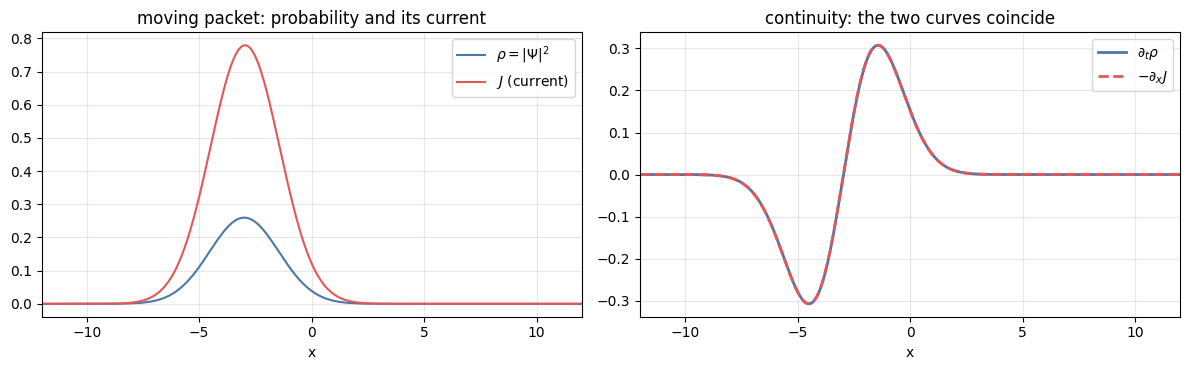

In [5]:
# plot the packet, its current, and the continuity balance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
ax1.plot(xg, rho, color="#4C78A8", label=r"$\rho=|\Psi|^2$")
ax1.plot(xg, J, color="#E45756", label=r"$J$ (current)")
ax1.set_xlim(-12, 12); ax1.set_xlabel("x"); ax1.set_title("moving packet: probability and its current")
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(xg, drho_dt, color="#4C78A8", lw=2, label=r"$\partial_t\rho$")
ax2.plot(xg, -dJdx, "--", color="#E45756", lw=2, label=r"$-\partial_x J$")
ax2.set_xlim(-12, 12); ax2.set_xlabel("x")
ax2.set_title("continuity: the two curves coincide"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## $dP_{ab}/dt=J(a)-J(b)$ as Kirchhoff's Current Law (Pandas)

Treat a region $(a,b)$ as a **circuit node**: probability current $J(a)$ flows *in* at the left,
$J(b)$ flows *out* at the right, and the "stored charge" is $P_{ab}=\int_a^b\rho\,dx$. Conservation
says accumulation = in $-$ out: $dP_{ab}/dt=J(a)-J(b)$ -- literally KCL. Check it across several
regions: the directly-measured $dP_{ab}/dt$ matches $J(a)-J(b)$.

In [6]:
def P_ab(rho_arr, ia, ib):
    return float(rho_arr[ia:ib].sum() * dx)

rho_next = psi_next.abs()**2
rows = []
for (xa, xb) in [(-8, -2), (-2, 4), (0, 6), (-10, 10)]:
    ia = int((xa - xg[0]) / dx); ib = int((xb - xg[0]) / dx)
    dP_dt = (P_ab(rho_next, ia, ib) - P_ab(rho, ia, ib)) / dt      # accumulation (measured)
    kcl = float(J[ia] - J[ib])                                     # J(a) - J(b)  (in - out)
    rows.append({"region (a,b)": f"({xa:+d},{xb:+d})",
                 "dP_ab/dt (accum.)": round(dP_dt, 5),
                 "J(a)-J(b) (in-out)": round(kcl, 5),
                 "abs diff": f"{abs(dP_dt-kcl):.2e}",
                 "KCL holds": abs(dP_dt - kcl) < 5e-3})
df = pd.DataFrame(rows)
print(df.to_string(index=False))
assert df["KCL holds"].all()
print("\ndP_ab/dt = J(a) - J(b): probability accumulation = current in - current out (KCL).")

region (a,b)  dP_ab/dt (accum.)  J(a)-J(b) (in-out) abs diff  KCL holds
     (-8,-2)           -0.64418            -0.63963 4.55e-03       True
     (-2,+4)            0.64757             0.64315 4.43e-03       True
     (+0,+6)            0.12397             0.12126 2.70e-03       True
   (-10,+10)            0.00002             0.00002 1.04e-06       True

dP_ab/dt = J(a) - J(b): probability accumulation = current in - current out (KCL).


## The dictionary: probability current $\leftrightarrow$ electric current

| quantum continuity | circuit / SPICE |
|---|---|
| probability density $\rho=|\Psi|^2$ | charge density $\rho_q$ (node charge $Q$) |
| probability current $J$ | electric current $I$ |
| $\partial_t\rho+\partial_x J=0$ | $\partial_t\rho_q+\partial_x J_q=0$ (charge conservation) |
| $dP_{ab}/dt=J(a)-J(b)$ | $dQ/dt=I_\text{in}-I_\text{out}$ (**KCL**) |
| Schrodinger equation | device equations ($I$-$V$ laws) |
| region $(a,b)$ | a **node** |

SPICE builds a circuit's operating point by writing KCL at every node -- the discrete continuity
equation $\sum I=0$ (or $=C\,dV/dt$ with storage). The same conservation law that makes $|\Psi|^2$ a
valid probability over all time makes charge add up at a node. `dgs.spice` (nodal analysis) and
`dgs.causality` (the continuity/Kramers-Kronig side) are this notebook's circuit-domain siblings.

## What we did

* **Proved** $\partial_t\rho+\partial_x J=0$ from the Schrodinger equation in SymPy, for *any*
  potential -- so $dP_{ab}/dt=J(a,t)-J(b,t)$; and found $J$ has units of probability per unit time.
* Computed $J$ for **Problem 1.9**: identically **zero** (real spatial part -> no flow), consistent
  with a time-independent $|\Psi|^2$.
* Evolved a **moving packet in Torch** and verified continuity numerically ($\partial_t\rho=-\partial_x J$),
  then confirmed $dP_{ab}/dt=J(a)-J(b)$ across regions in a **Pandas** table.
* Read that identity as **Kirchhoff's Current Law** -- the probability current is an electric current,
  a region is a node, and SPICE's nodal analysis is the continuity equation in a circuit.

Continues the Chapter-1 arc; here the bridge runs straight from quantum mechanics to computer
engineering: conservation laws don't care which vocabulary you use.